# Cybersecurity Regularized Regression Modeling

**Author:** Usha Priya Krishnasamy  
**Project Type:** Regularized regression, cross-validation, coefficient review, and model comparison  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15
#### Project Overview

This notebook applies regularized regression models across three cybersecurity datasets used for threat detection, anomaly analysis, and attack classification.

The workflow compares Ridge, Lasso, and Elastic Net regression using cross-validation, selected alpha values, coefficient review, and model performance metrics.

Although the main cybersecurity objective is classification, regularized regression is used here as a baseline modeling and feature-diagnostic step before moving to classification models.

The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.
 

In [1]:
# Dataset loading 

## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

### Libraries for train test split and models

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


########  polynomial libraires
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor

#########  Linraies for Regularised regression
 
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
 
## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\32
['cybersecurity_attacks.csv', 'README.md']


## 1.BETH dataset

In [2]:
# Dataset preparation 

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")

X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')


In [3]:
X_train_beth.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args
1060840,472.442379,7555,7555,7548,1001,4026531840,249,5,3,8,112473,1,0,183909
608882,914.843280,7282,7282,187,0,4026532217,94,11,257,28,48426,4,15,160353
56548,2886.683328,7369,7369,1317,0,4026531840,72,0,3,8,112473,1,0,186766
1071941,479.252498,7555,7555,7548,1001,4026531840,249,5,42,9,112473,3,-114,260097
695524,550.777799,7318,7318,7099,0,4026531840,82,9,1005,32,18441,4,0,225439


In [4]:
y_train_beth.head()

1060840    1
608882     0
56548      0
1071941    1
695524     0
Name: evil, dtype: int64

#### Target Selection Note

The BETH dataset contains binary cybersecurity labels, including `evil` and `sus`.

In this section, `evil` is used as the target variable. Because `evil` is a binary 0/1 label, this is not a true continuous regression problem. Ridge, Lasso, and Elastic Net are used here as regularized linear baseline models to study coefficient stability, regularization behavior, and feature influence.

These results should be interpreted as a baseline diagnostic step. Final attack-detection modeling should use classification models and classification metrics such as recall, F1-score, ROC-AUC, and confusion matrices.

Regularized Regression Results with CV (BETH Dataset):
              RMSE      R2  Best Alpha  Best l1_ratio
Ridge       0.0628  0.9671    8.286428            NaN
Lasso       0.0629  0.9669    0.001000            NaN
ElasticNet  0.0628  0.9670    0.001000            0.1


<Figure size 1400x700 with 0 Axes>

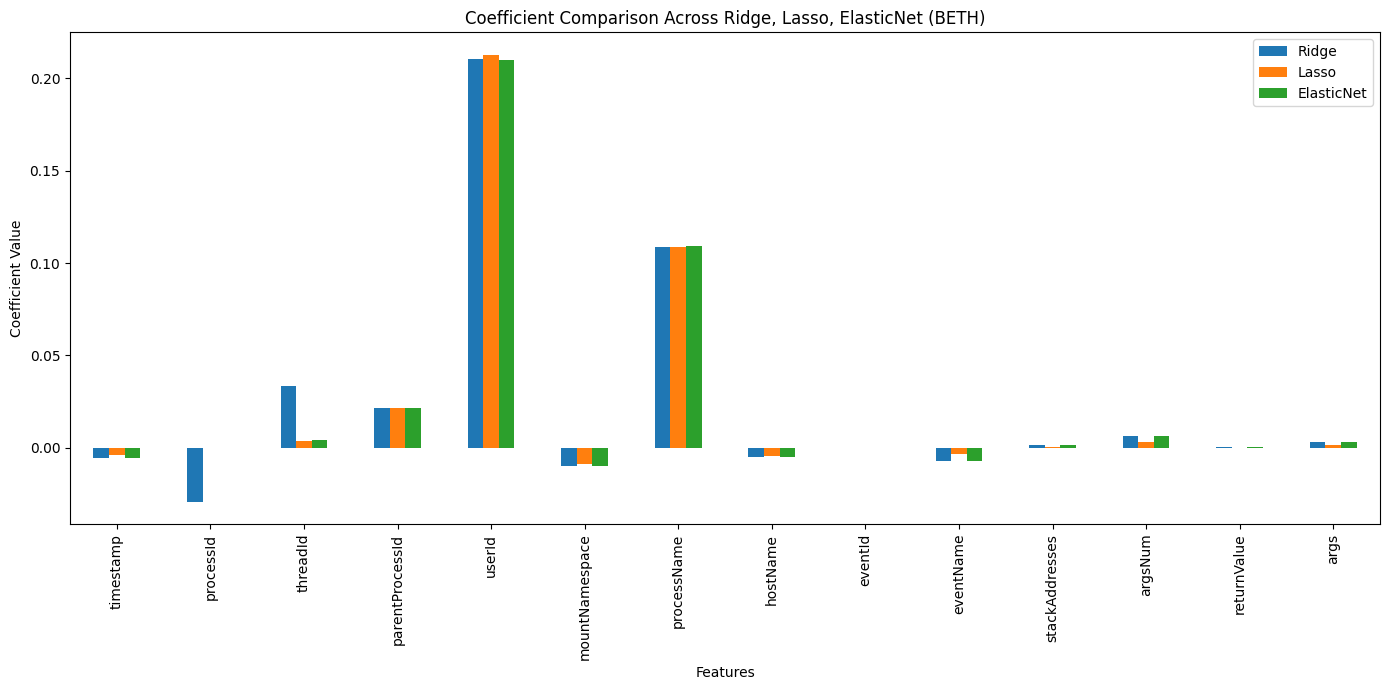

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1572289728.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


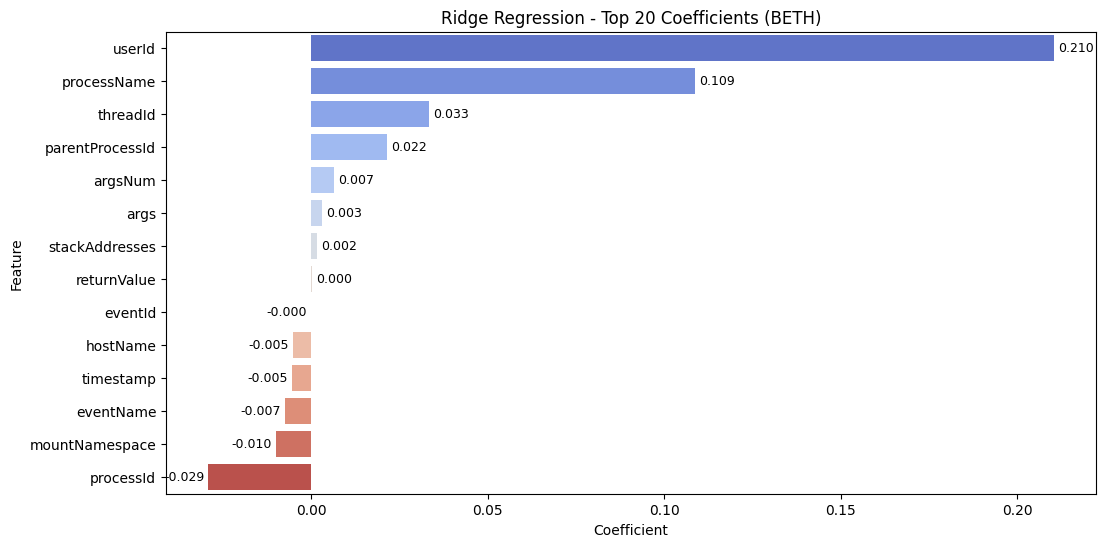

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1572289728.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


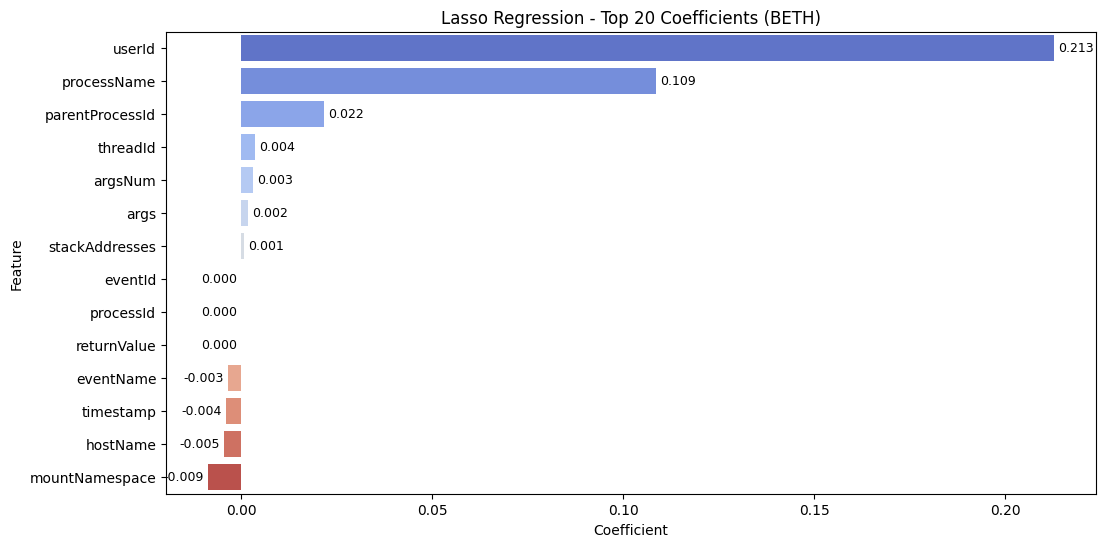

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1572289728.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


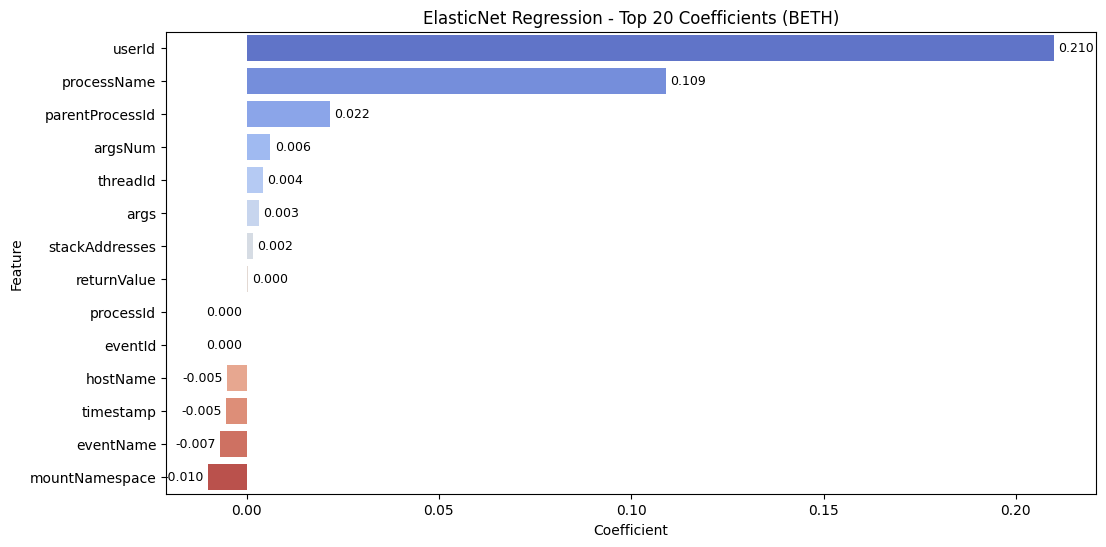

,RMSE,R2,Best Alpha,Best l1_ratio
Ridge,0.0628,0.9671,8.286428,NaN
Lasso,0.0629,0.9669,0.001000,NaN
ElasticNet,0.0628,0.9670,0.001000,0.1


In [5]:

# -------------------- Define alphas and CV models --------------------
alphas = np.logspace(-3, 3, 50)

models = {
    'Ridge': RidgeCV(alphas=alphas, cv=5),
    'Lasso': LassoCV(alphas=alphas, cv=5, max_iter=5000),
    'ElasticNet': ElasticNetCV(alphas=alphas, l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5, max_iter=5000)
}

results = {}
coef_storage = {}

# -------------------- Train & Evaluate --------------------
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    pipeline.fit(X_train_beth, y_train_beth)
    y_pred = pipeline.predict(X_test_beth)

    # Store performance
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test_beth, y_pred)),
        'R2': r2_score(y_test_beth, y_pred),
        'Best Params': {
            'alpha': getattr(pipeline.named_steps['regressor'], 'alpha_', None),
            'l1_ratio': getattr(pipeline.named_steps['regressor'], 'l1_ratio_', None)
        },
        'Model': pipeline
    }

    # Store coefficients
    coef_storage[name] = pipeline.named_steps['regressor'].coef_

# -------------------- Summarize results --------------------
results_df_beth = pd.DataFrame({
    model: {
        'RMSE': round(metrics['RMSE'], 4),
        'R2': round(metrics['R2'], 4),
        'Best Alpha': metrics['Best Params']['alpha'],
        'Best l1_ratio': metrics['Best Params']['l1_ratio']
    }
    for model, metrics in results.items()
}).T

print("Regularized Regression Results with CV (BETH Dataset):")
print(results_df_beth)

# -------------------- Combined Coefficient Comparison --------------------
coef_df = pd.DataFrame(coef_storage, index=X_train_beth.columns)

plt.figure(figsize=(14, 7))
coef_df.plot(kind='bar', figsize=(14, 7))
plt.title("Coefficient Comparison Across Ridge, Lasso, ElasticNet (BETH)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# -------------------- Individual Top 20 Coefficients --------------------
for name, coefs in coef_storage.items():
    df_temp = pd.DataFrame({'Feature': X_train_beth.columns, 'Coefficient': coefs})
    df_temp = df_temp.sort_values(by='Coefficient', ascending=False)

    if (df_temp['Coefficient'] == 0).all():
        print(f"All coefficients for {name} are zero. No plot to display.")
        continue

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_temp.head(20),
        x='Coefficient',
        y='Feature',
        palette='coolwarm'
    )
    plt.title(f"{name} Regression - Top 20 Coefficients (BETH)")

    # Annotate coefficient values
    for p in ax.patches:
        coeff = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{coeff:.3f}', (coeff, y),
                    ha='left' if coeff > 0 else 'right',
                    va='center',
                    fontsize=9,
                    color='black',
                    xytext=(3 if coeff > 0 else -3, 0),
                    textcoords='offset points')
    plt.show()
##################################################################################333333

results_df_beth

#### BETH Dataset Findings

Cross-validated Ridge, Lasso, and Elastic Net were applied to the BETH dataset using `evil` as the target variable.

Because `evil` is a binary 0/1 label, these models should be interpreted as regularized linear baseline models rather than final classification models.

Ridge produced the strongest baseline result, with similar performance to Lasso and Elastic Net. The results suggest that host-level features such as process, user, event, host, and namespace-related variables contain useful signal for identifying malicious activity.

However, final cybersecurity model evaluation should rely on classification models such as logistic regression, random forest, gradient boosting, or SVM, using metrics such as recall, F1-score, ROC-AUC, and confusion matrices.

## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [6]:
#print(df_csa.columns.to_list())
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data','Proxy Information','Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_new_csa["Malware Indicators"] = df_new_csa["Malware Indicators"].fillna("None Detected")
df_new_csa["Alerts/Warnings"] = df_new_csa["Alerts/Warnings"].fillna("No Alert")
df_csa_encoded = df_new_csa.copy()

# Define categorical columns (assuming csa_categorical_columns is defined elsewhere)
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

# Convert Timestamp to datetime and verify
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
if df_csa_encoded['Timestamp'].dtype != 'datetime64[ns]':
    print("Warning: Timestamp column is not datetime64[ns]. Checking for issues...")
    print(df_csa_encoded['Timestamp'].head())  # Debug: Check the first few values
    df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with NaT if needed

# Extract time components
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode all categorical columns
label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Combine all numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number')

# Handle any remaining NaN values
df_features = df_features.fillna(0)


csa_numeric_columns=df_features.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_features.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

######################################################################################################


X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(df_features.drop(columns=['Anomaly Scores']), df_features['Anomaly Scores'], test_size=0.2, random_state=0)




Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts', 'Hour', 'Weekday', 'Month']


Categorical columns in the dataset:

[]


#### (ii) Lasso, Ridge and Elastic net regression

##### Note on Target Selection: After lable encoding all the categorical varaibles, the anomaly scores is seelcted as target for prediciton.Using anomaly scores as a continuous target allows experimentation with regression models, but it does not fully reflect the dataset’s intended purpose. For practical attack detection, a binary target (e.g., malicious vs. benign) would be more appropriate.


Regularized Regression Results with CV (Cybersecurity Dataset):
               RMSE      R2  Best Alpha  Best l1_ratio
Ridge       28.7703 -0.0006      1000.0            NaN
Lasso       28.7626 -0.0001      1000.0            NaN
ElasticNet  28.7626 -0.0001      1000.0            0.1


<Figure size 1400x700 with 0 Axes>

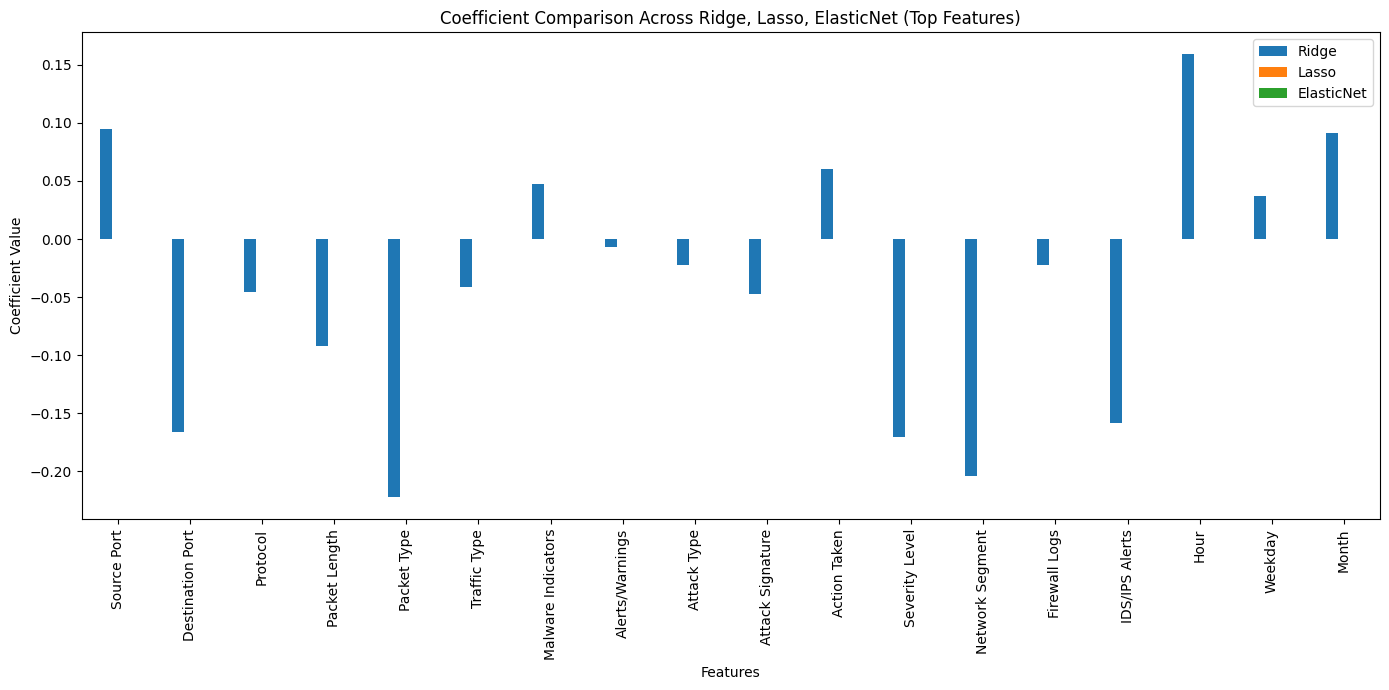

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\3027302812.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


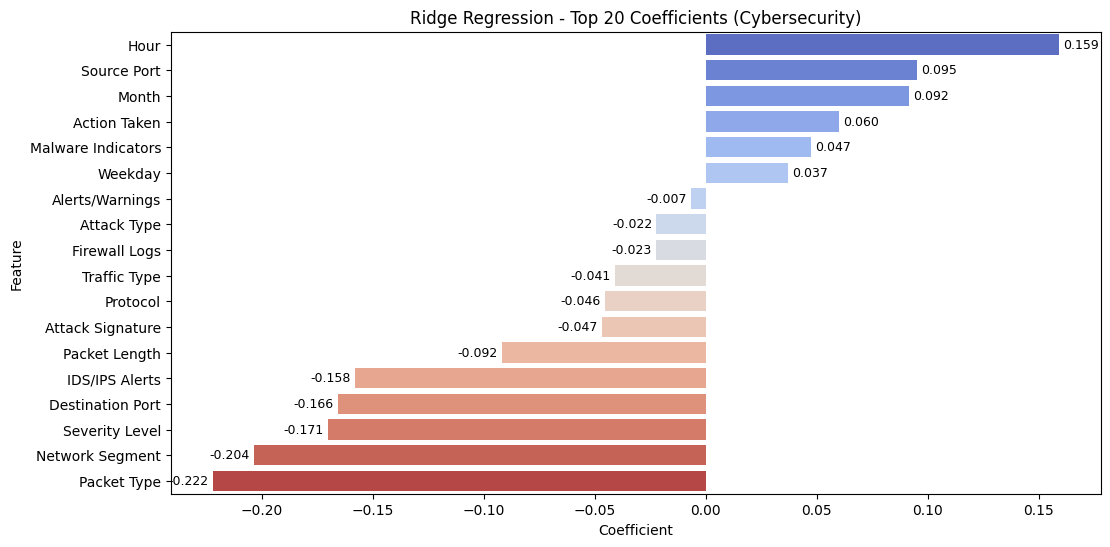

All coefficients for Lasso are zero. No plot to display.
All coefficients for ElasticNet are zero. No plot to display.


,RMSE,R2,Best Alpha,Best l1_ratio
Ridge,28.7703,-0.0006,1000.0,NaN
Lasso,28.7626,-0.0001,1000.0,NaN
ElasticNet,28.7626,-0.0001,1000.0,0.1


In [7]:
# -------------------- Prepare CV Models --------------------
alphas = np.logspace(-3, 3, 50)

models = {
    'Ridge': RidgeCV(alphas=alphas, cv=5),
    'Lasso': LassoCV(alphas=alphas, cv=5, max_iter=5000),
    'ElasticNet': ElasticNetCV(alphas=alphas, l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5, max_iter=5000)
}

results = {}
coef_storage = {}

# -------------------- Train & Evaluate --------------------
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    pipeline.fit(X_train_csa, y_train_csa)
    y_pred = pipeline.predict(X_test_csa)

    # Store performance
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test_csa, y_pred)),
        'R2': r2_score(y_test_csa, y_pred),
        'Best Params': {
            'alpha': getattr(pipeline.named_steps['regressor'], 'alpha_', None),
            'l1_ratio': getattr(pipeline.named_steps['regressor'], 'l1_ratio_', None)
        },
        'Model': pipeline
    }

    # Store coefficients
    coef_storage[name] = pipeline.named_steps['regressor'].coef_

# -------------------- Summarize results --------------------
results_df_csa = pd.DataFrame({
    model: {
        'RMSE': round(metrics['RMSE'], 4),
        'R2': round(metrics['R2'], 4),
        'Best Alpha': metrics['Best Params']['alpha'],
        'Best l1_ratio': metrics['Best Params']['l1_ratio']
    }
    for model, metrics in results.items()
}).T

print("Regularized Regression Results with CV (Cybersecurity Dataset):")
print(results_df_csa)

# -------------------- Combined Coefficient Comparison --------------------
coef_df = pd.DataFrame(coef_storage, index=X_train_csa.columns)

plt.figure(figsize=(14, 7))
coef_df.plot(kind='bar', figsize=(14, 7))
plt.title("Coefficient Comparison Across Ridge, Lasso, ElasticNet (Top Features)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# -------------------- Individual Top 20 Coefficients --------------------
for name, coefs in coef_storage.items():
    df_temp = pd.DataFrame({'Feature': X_train_csa.columns, 'Coefficient': coefs})
    df_temp = df_temp.sort_values(by='Coefficient', ascending=False)

    if (df_temp['Coefficient'] == 0).all():
        print(f"All coefficients for {name} are zero. No plot to display.")
        continue

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_temp.head(20),
        x='Coefficient',
        y='Feature',
        palette='coolwarm'
    )
    plt.title(f"{name} Regression - Top 20 Coefficients (Cybersecurity)")

    # Annotate coefficient values
    for p in ax.patches:
        coeff = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{coeff:.3f}', (coeff, y),
                    ha='left' if coeff > 0 else 'right',
                    va='center',
                    fontsize=9,
                    color='black',
                    xytext=(3 if coeff > 0 else -3, 0),
                    textcoords='offset points')
    plt.show()

results_df_csa

### Conclusion 
Model Selection and Regularization: Cross-validated Ridge, Lasso, and ElasticNet all selected very high alpha values (≈1000), reflecting strong regularization. Lasso and ElasticNet completely shrank coefficients to zero, while ElasticNet leaned toward Ridge-like behavior (l1_ratio = 0.1).

Predictive Performance: All models showed very low predictive power (R² ≈ 0 or slightly negative, RMSE ~28.76), indicating that linear relationships between features and anomaly scores are extremely weak or noisy.

Feature Impact: Only Ridge retained some coefficients, highlighting minor contributions from time-related features (Hour, Month) and network activity features (Source Port, Packet Type, Traffic Type). Lasso and ElasticNet were unable to identify any predictive features due to over-regularization.

Recommendation: These results suggest that anomaly detection in cybersecurity data is highly non-linear. To better capture complex patterns, non-linear or ensemble methods such as Random Forests, Gradient Boosting, or Neural Networks should be employed for improved predictive accuracy.


## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis  

In [8]:
unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'label' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric.to_list())
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical.to_list())

Numeric columns in the dataset:

['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


Categorical columns in the dataset:

[]


#### (ii) Lasso, Ridge and Elastic net regression with cross validation

##### Note on Target Selection:  The binary label (normal vs. attack) is used as the target to explore linear regression with regularization.

Regularized Regression Results (with CV tuning):


<Figure size 1400x700 with 0 Axes>

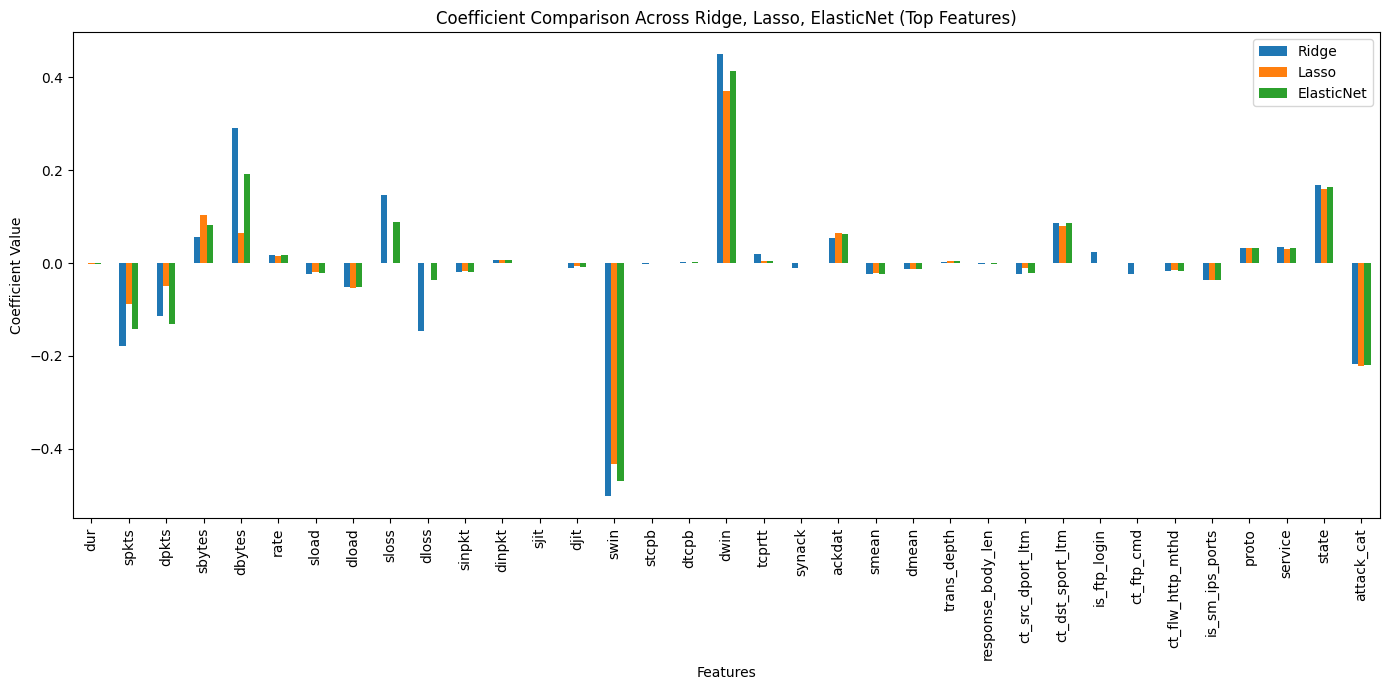

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1329656512.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


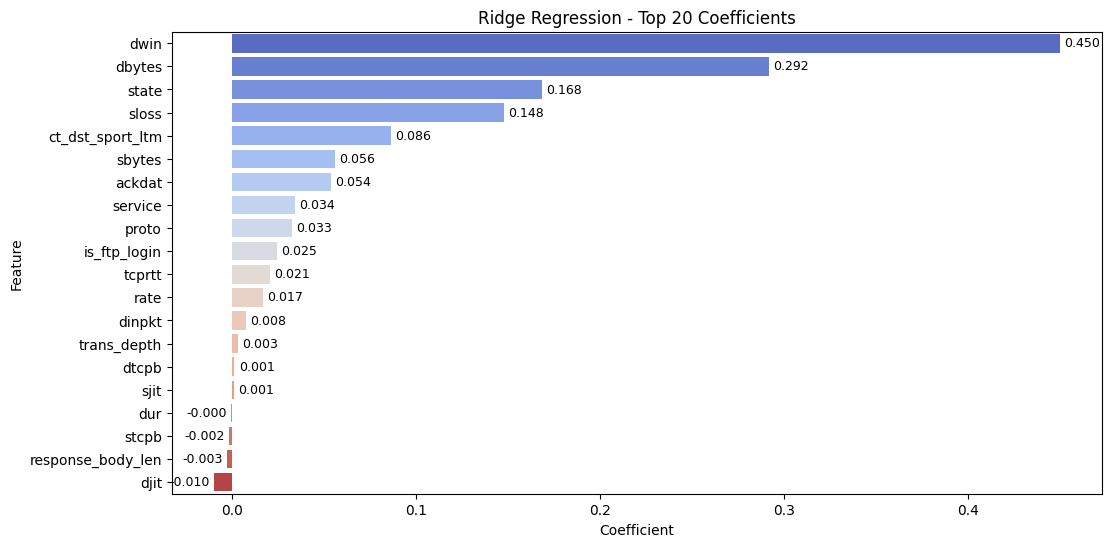

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1329656512.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


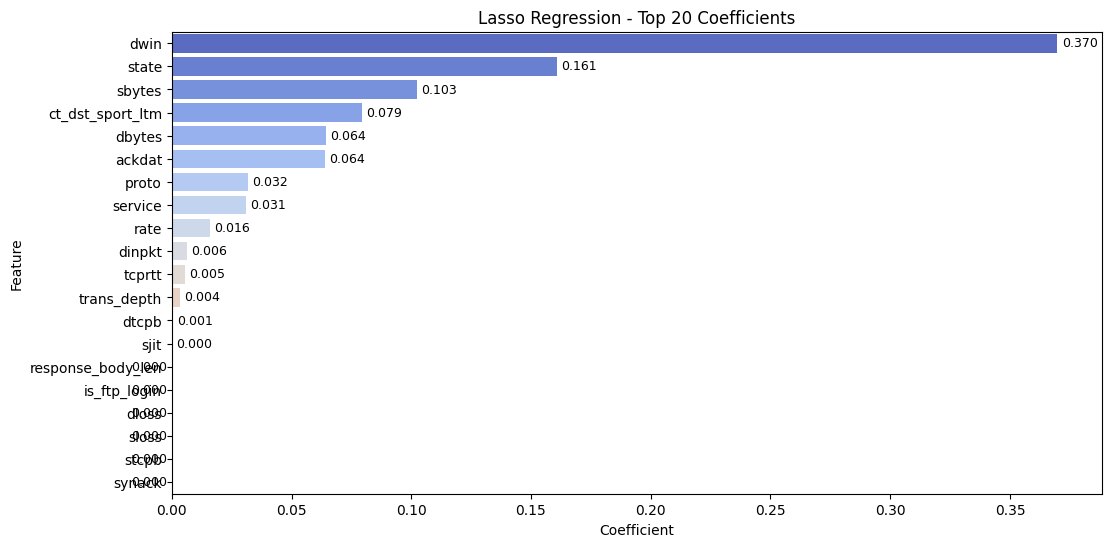

C:\Users\phxlab\AppData\Local\Temp\ipykernel_3800\1329656512.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


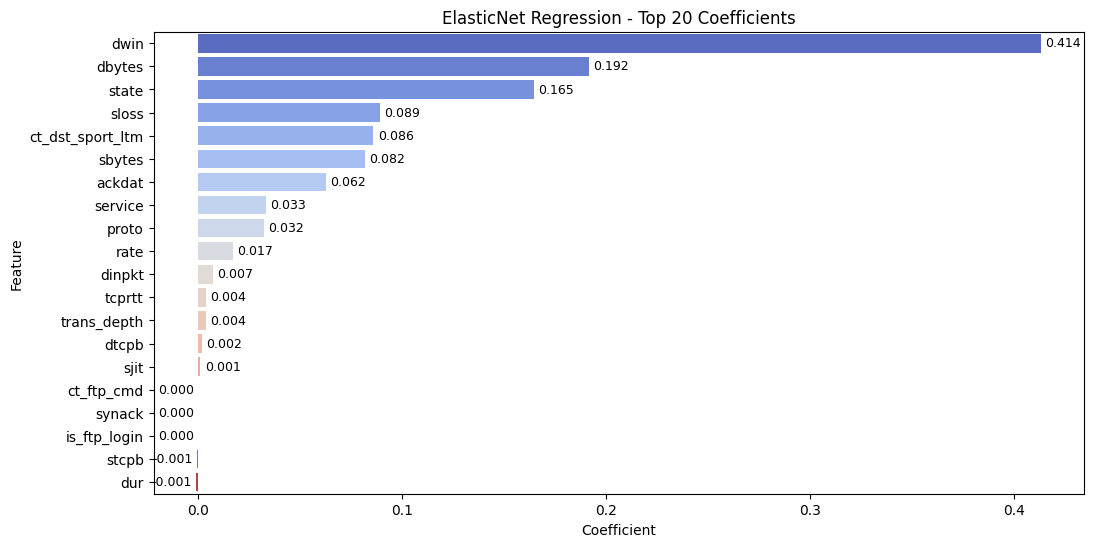

,RMSE,R2,Best Alpha,Best l1_ratio
Ridge,0.2807,0.6588,8.286428,NaN
Lasso,0.2819,0.6559,0.001000,NaN
ElasticNet,0.2810,0.6582,0.001000,0.1


In [9]:
# -------------------- Models with CV --------------------
alphas = np.logspace(-3, 3, 50)

models = {
    'Ridge': RidgeCV(alphas=alphas, cv=5),
    'Lasso': LassoCV(alphas=alphas, cv=5, max_iter=5000),
    'ElasticNet': ElasticNetCV(alphas=alphas, l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5, max_iter=5000)
}

results = {}
coef_storage = {}

# -------------------- Train & Evaluate --------------------
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Store performance
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'Best Params': {
            'alpha': getattr(pipeline.named_steps['regressor'], 'alpha_', None),
            'l1_ratio': getattr(pipeline.named_steps['regressor'], 'l1_ratio_', None)
        },
        'Model': pipeline
    }

    # Store coefficients
    coef_storage[name] = pipeline.named_steps['regressor'].coef_

# -------------------- Summarize results --------------------
results_df_unsw = pd.DataFrame({
    model: {
        'RMSE': round(metrics['RMSE'], 4),
        'R2': round(metrics['R2'], 4),
        'Best Alpha': metrics['Best Params']['alpha'],
        'Best l1_ratio': metrics['Best Params']['l1_ratio']
    }
    for model, metrics in results.items()
}).T

print("Regularized Regression Results (with CV tuning):")
#print(results_df)

# -------------------- Combined Coefficient Comparison --------------------
coef_df = pd.DataFrame(coef_storage, index=X_train.columns)

plt.figure(figsize=(14, 7))
coef_df.plot(kind='bar', figsize=(14, 7))
plt.title("Coefficient Comparison Across Ridge, Lasso, ElasticNet (Top Features)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# -------------------- Individual Top 20 Coefficients --------------------
for name, coefs in coef_storage.items():
    df_temp = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefs})
    df_temp = df_temp.sort_values(by='Coefficient', ascending=False)

    if (df_temp['Coefficient'] == 0).all():
        print(f"All coefficients for {name} are zero. No plot to display.")
        continue

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_temp.head(20),
        x='Coefficient',
        y='Feature',
        palette='coolwarm'
    )
    plt.title(f"{name} Regression - Top 20 Coefficients")

    # Annotate coefficient values
    for p in ax.patches:
        coeff = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f'{coeff:.3f}', (coeff, y),
                    ha='left' if coeff > 0 else 'right',
                    va='center',
                    fontsize=9,
                    color='black',
                    xytext=(3 if coeff > 0 else -3, 0),
                    textcoords='offset points')
    plt.show()
    ###########################################################################3

results_df_unsw

### Conclusion 
Ridge Regression came out strongest, with the lowest error and best fit (RMSE ≈ 0.28, R² ≈ 0.66, α ≈ 8.3). This means adding an L2 penalty helped the model stay stable and balanced.

Lasso and ElasticNet ended up choosing very small alpha values (0.001). In practice, this means they behaved almost like plain regression and didn’t remove many features.

Important features like sbytes, dbytes, swin, and dwin stood out, showing they are key indicators for spotting unusual network activity.

Overall, while this dataset is binary, the results show that Ridge regularization works best here. If we moved to a proper classification model, a Ridge-style Logistic Regression would likely be the right choice.